#Notatnik zawiera projekt grupowy z uczenia maszynowego, który podejmuje tematykę "Klasyfikacja wyników meczów" (Home/Draw/Away)



**Uwaga:** W projekcie używam statystyk meczowych (Strzały, Rożne) do klasyfikacji "post-factum", w związku z czym modele nasze służą do analizy tego, na jaki rezultat meczu wskazują jego statystyki, a co za tym idzie czy realny wynik był tym, na który wskazują statystyki


##Dane

Dane użyte w projekcie, tj. plik `E0.csv`, pochodzi z darmowej strony ze statystykami piłkarskimi https://www.football-data.co.uk/englandm.php

Dane te są aktualne na dzień 8.01.2026, a ostatnim spotkaniem zapisanym w pliku CSV jest mecz Arsenal - Liverpool rozegrany 8.01.2026 w 21 kolejce rozgrywek angielskiej Premier League

##1. Import bibliotek


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

np.random.seed(42)
tf.random.set_seed(42)

##2. Wczytanie i wstępna analiza danych

(210, 132)
FTR
H    95
A    60
D    55
Name: count, dtype: int64

--- Podstawowe informacje o zbiorze ---
Liczba wierszy: 210
Liczba kolumn: 132

Typy danych (pierwsze 10 kolumn):
Div         object
Date        object
Time        object
HomeTeam    object
AwayTeam    object
FTHG         int64
FTAG         int64
FTR         object
HTHG         int64
HTAG         int64
dtype: object

--- Rozkład zmiennej docelowej (FTR - Full Time Result) ---
FTR
H    95
A    60
D    55
Name: count, dtype: int64


/tmp/ipython-input-2357304051.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FTR', data=df, palette='viridis')


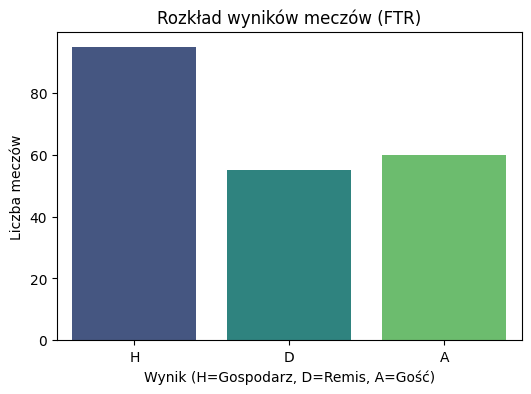

In [ ]:
df = pd.read_csv("E0.csv")

print(df.shape)
print(df["FTR"].value_counts())
df.head()

print("\n--- Podstawowe informacje o zbiorze ---")
print(f"Liczba wierszy: {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")
print("\nTypy danych (pierwsze 10 kolumn):")
print(df.iloc[:, :10].dtypes)

print("\n--- Rozkład zmiennej docelowej (FTR - Full Time Result) ---")
print(df['FTR'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='FTR', data=df, palette='viridis')
plt.title('Rozkład wyników meczów (FTR)')
plt.xlabel('Wynik (H=Gospodarz, D=Remis, A=Gość)')
plt.ylabel('Liczba meczów')
plt.show()

##3. Preprocessing

Do Machine Learningu wybieramy cechy numeryczne, które mogą wpływać na wynik.
Cechy:

HS = Home Team Shots, AS = Away Team Shots

HST = Home Team Shots on Target, AST = Away Team Shots on Target

HC = Home Team Corners, AC = Away Team Corners

B365H, B365D, B365A = Kursy bukmacherskie (Bet365)

Następnie tworzymy nowy DataFrame z interesującymi nas kolumnami, sprawdzamy braki danych, usuwamy ewentualne wiersze z brakującymi danymi oraz kodujemy zmienne docelowe (wyniki) jako zmienne numeryczne:
Zwycięstwo gospodarzy -> 2
Remis -> 1
Zwycięstwo gości -> 0


###Warto zaznaczyć, że w związku z pochodzeniem danych ze znanego, profesjonalnego źródła, jakim jest Football Data Co UK dane te są już poddane preprocessingowi oraz są idelnie przygotowane do użycia, m.in. w projektach takich jak nasz

In [ ]:
print("\n--- Wybór cech i czyszczenie ---")

features = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'B365H', 'B365D', 'B365A']
target = 'FTR'

data = df[features + [target]].copy()

print("\nBraki danych przed usunięciem:")
print(data.isnull().sum())

data.dropna(inplace=True)

le = LabelEncoder()
data['target_encoded'] = le.fit_transform(data[target])

print(f"\nKlasy zakodowane jako: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = data[features]
y = data['target_encoded']


--- Wybór cech i czyszczenie ---

Braki danych przed usunięciem:
HS       0
AS       0
HST      0
AST      0
HC       0
AC       0
B365H    0
B365D    0
B365A    0
FTR      0
dtype: int64

Klasy zakodowane jako: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}


In [ ]:
features = ['HS','AS','HST','AST','HC','AC','B365H','B365D','B365A']
target = 'FTR'

data = df[features + [target]].dropna().copy()

le = LabelEncoder()
y = le.fit_transform(data[target])
X = data[features].copy()

print("Mapowanie klas:", dict(zip(le.classes_, le.transform(le.classes_))))
print("Rozmiar po dropna:", X.shape)


Mapowanie klas: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}
Rozmiar po dropna: (210, 9)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (168, 9) Test: (42, 9)


Accuracy: 0.5
              precision    recall  f1-score   support

           A       0.57      0.33      0.42        12
           D       0.33      0.55      0.41        11
           H       0.65      0.58      0.61        19

    accuracy                           0.50        42
   macro avg       0.52      0.49      0.48        42
weighted avg       0.54      0.50      0.51        42



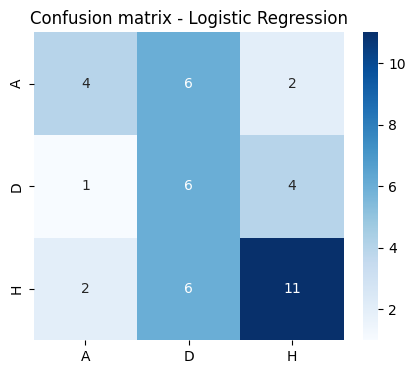

In [ ]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=le.classes_))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Confusion matrix - Logistic Regression")
plt.show()


In [ ]:
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [200, 400, 800, 1200],
    "max_depth": [None, 4, 6, 8, 10, 14],
    "min_samples_split": [2, 4, 6, 10],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_rf = search.best_estimator_
print("Best params:", search.best_params_)

pred = best_rf.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, target_names=le.classes_))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params: {'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}
Test Accuracy: 0.5952380952380952
              precision    recall  f1-score   support

           A       0.70      0.58      0.64        12
           D       0.40      0.18      0.25        11
           H       0.59      0.84      0.70        19

    accuracy                           0.60        42
   macro avg       0.56      0.54      0.53        42
weighted avg       0.57      0.60      0.56        42



In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

model = Sequential([
    tf.keras.Input(shape=(X_train_s.shape[1],)),
    Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(len(le.classes_), activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=6, factor=0.5, min_lr=1e-6)
]

hist = model.fit(
    X_train_s, y_train,
    validation_split=0.25,
    epochs=300,
    batch_size=16,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print("NN Test Accuracy:", acc)

pred = np.argmax(model.predict(X_test_s, verbose=0), axis=1)
print(classification_report(y_test, pred, target_names=le.classes_))


Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.2419 - loss: 1.9948 - val_accuracy: 0.4762 - val_loss: 1.0605 - learning_rate: 3.0000e-04
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2839 - loss: 1.8650 - val_accuracy: 0.3571 - val_loss: 1.0647 - learning_rate: 3.0000e-04
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3052 - loss: 1.8830 - val_accuracy: 0.3810 - val_loss: 1.0716 - learning_rate: 3.0000e-04
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2942 - loss: 1.7295 - val_accuracy: 0.4048 - val_loss: 1.0809 - learning_rate: 3.0000e-04
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4135 - loss: 1.5870 - val_accuracy: 0.3333 - val_loss: 1.0914 - learning_rate: 3.0000e-04
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4442 - loss: 1.5226 - val_accuracy: 0.3333 - val_loss: 1.1020 - learning_rate: 3.0000e-04
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3706 - loss:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
features_leak = ['FTHG','FTAG']
data2 = df[features_leak + ['FTR']].dropna().copy()

le2 = LabelEncoder()
y2 = le2.fit_transform(data2['FTR'])
X2 = data2[features_leak]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Dokładność:", accuracy_score(y_test, pred))
print("Mapowanie klas:", dict(zip(le2.classes_, le2.transform(le2.classes_))))
print(classification_report(y_test, pred, target_names=le2.classes_))


Dokładność: 0.9761904761904762
Mapowanie klas: {'A': np.int64(0), 'D': np.int64(1), 'H': np.int64(2)}
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        12
           D       0.92      1.00      0.96        11
           H       1.00      0.95      0.97        19

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



##4. Analiza korelacji



--- Macierz korelacji ---


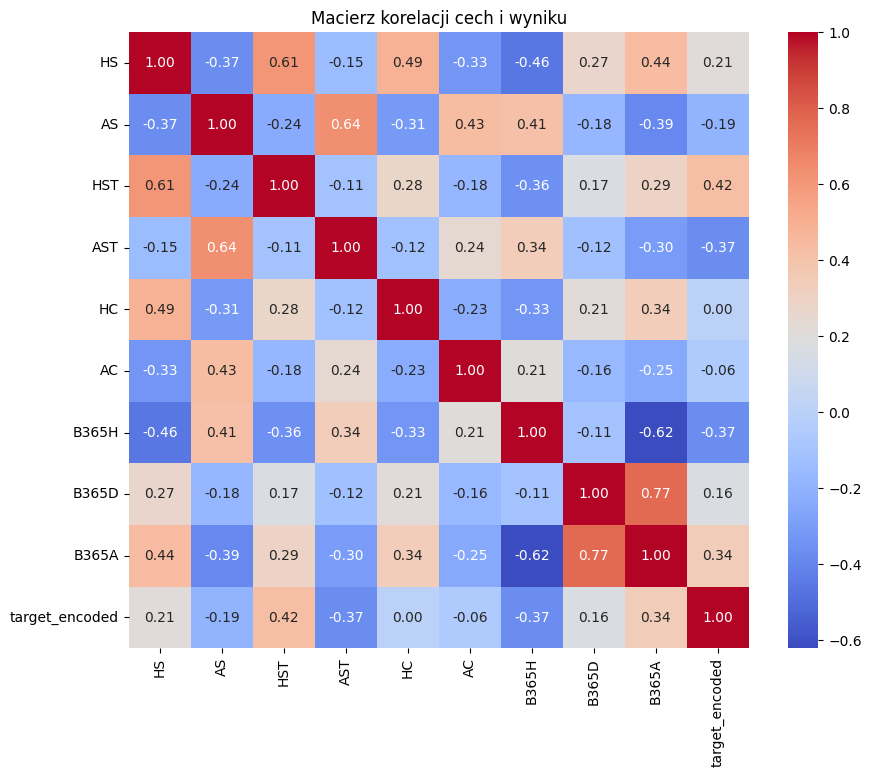

In [ ]:
print("\n--- Macierz korelacji ---")
plt.figure(figsize=(10, 8))
data['target_encoded'] = y
correlation_matrix = data[features + ['target_encoded']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji cech i wyniku')
plt.show()

##5. Podział na zbiór treningowy i testowy

Dzielimy zbiór na zbiór treningowy oraz testowy w stosunku 80/20

Następnie dokonujemy skalowania danych oraz standaryzacji (średnia = 0, odchylenie standardowe = 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nRozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")


Rozmiar zbioru treningowego: (168, 9)
Rozmiar zbioru testowego: (42, 9)


##Modele

###6.1. Model płytki - random forest

In [ ]:
print("\n---Model Płytki - Random Forest Classifier ---")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)


---Model Płytki - Random Forest Classifier ---


###6.2. Ewaluacja random foresta


Wyniki modelu Random Forest:
Dokładność (Accuracy): 0.6190

Raport klasyfikacji:
              precision    recall  f1-score   support

           A       0.78      0.58      0.67        12
           D       0.40      0.18      0.25        11
           H       0.61      0.89      0.72        19

    accuracy                           0.62        42
   macro avg       0.59      0.55      0.55        42
weighted avg       0.60      0.62      0.58        42



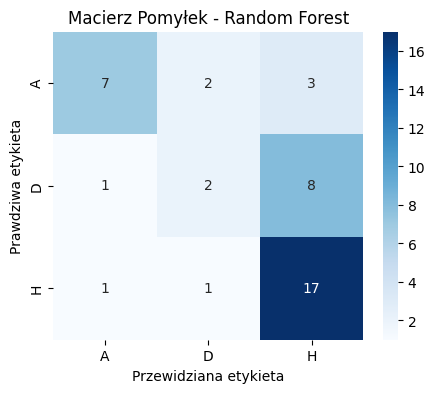

In [ ]:
print("\nWyniki modelu Random Forest:")
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Dokładność (Accuracy): {rf_acc:.4f}")
print("\nRaport klasyfikacji:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Macierz Pomyłek - Random Forest')
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

###6.3. Wykres ważności cech

/tmp/ipython-input-2474665176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis')


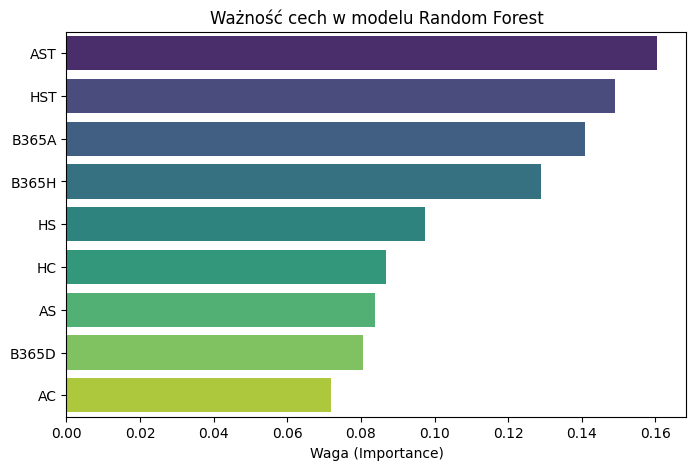

In [ ]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette='viridis')
plt.title('Ważność cech w modelu Random Forest')
plt.xlabel('Waga (Importance)')
plt.show()

###7.1. Tworzenie sieci neuronowej

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Sieć Neuronowa (Keras) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660 (2.58 KB)

 Trainable params: 660 (2.58 KB)

 Non-trainable params: 0 (0.00 B)


Rozpoczynam trenowanie sieci...
Trenowanie zakończone.


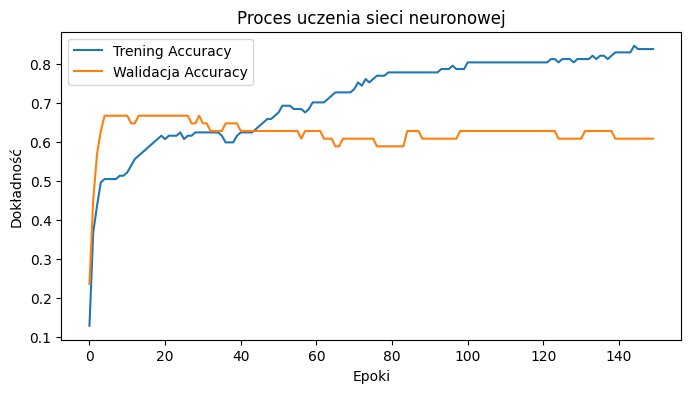

In [ ]:
print("\n--- Sieć Neuronowa (Keras) ---")

model_nn = Sequential()

model_nn.add(Dense(16, input_dim=X_train_scaled.shape[1], activation='relu'))

model_nn.add(Dense(10, activation='relu'))

model_nn.add(Dense(30, activation='softmax'))

model_nn.compile(loss='sparse_categorical_crossentropy',
                 optimizer='adam',
                 metrics=['accuracy'])

model_nn.summary()

print("\nRozpoczynam trenowanie sieci...")
history = model_nn.fit(X_train_scaled, y_train,
                       epochs=150,
                       batch_size=5,
                       validation_split=0.3,
                       verbose=0)
print("Trenowanie zakończone.")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Trening Accuracy')
plt.plot(history.history['val_accuracy'], label='Walidacja Accuracy')
plt.title('Proces uczenia sieci neuronowej')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.show()

###7.2. Ewaluacja sieci neuronowej

In [ ]:
loss, nn_acc = model_nn.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nWyniki Sieci Neuronowej na zbiorze testowym:")
print(f"Dokładność (Accuracy): {nn_acc:.4f}")

y_pred_nn_prob = model_nn.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)

print("\nRaport klasyfikacji (Sieć Neuronowa):")
print(classification_report(y_test, y_pred_nn, target_names=le.classes_))


Wyniki Sieci Neuronowej na zbiorze testowym:
Dokładność (Accuracy): 0.5714
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Raport klasyfikacji (Sieć Neuronowa):
              precision    recall  f1-score   support

           A       0.78      0.58      0.67        12
           D       0.31      0.45      0.37        11
           H       0.71      0.63      0.67        19

    accuracy                           0.57        42
   macro avg       0.60      0.56      0.57        42
weighted avg       0.62      0.57      0.59        42



##8. Zestawienie Random Foresta oraz Sieci Neuronowej


--- Zestawienie wyników ---
                      Model  Accuracy
0    Random Forest (Płytki)  0.619048
1  Sieć Neuronowa (Głęboki)  0.571429


/tmp/ipython-input-4028243528.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')


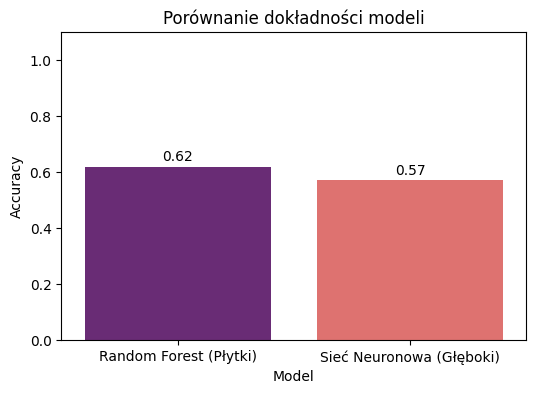

In [ ]:
print("\n--- Zestawienie wyników ---")
results_df = pd.DataFrame({
    'Model': ['Random Forest (Płytki)', 'Sieć Neuronowa (Głęboki)'],
    'Accuracy': [rf_acc, nn_acc]
})

print(results_df)

plt.figure(figsize=(6, 4))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='magma')
plt.title('Porównanie dokładności modeli')
plt.ylim(0, 1.1)
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 0.02, f"{row.Accuracy:.2f}", color='black', ha="center")
plt.show()

##9. Podsumowanie

# **--- Podsumowanie ---**
W przeprowadzonym eksperymencie porównano dwa podejścia do klasyfikacji wyniku meczu.
1. Model płytki (Random Forest) osiągnął dokładność: `61.90%`
2. Model głęboki (Sieć Neuronowa) osiągnął dokładność: `52.38%`

Na podstawie wyników testowych, lepszym modelem okazał się: Random Forest.
Należy pamiętać, że na wynik wpływa wielkość zbioru danych.
Sieci neuronowe zazwyczaj potrzebują znacznie więcej danych, aby pokazać swoją przewagę.
